In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer

In [4]:
data = load_breast_cancer()
df = pd.DataFrame(data.data,columns=data.feature_names)
df["target"] = data.target
X=df.drop("target",axis=1)
y=df["target"]

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
rf = RandomForestClassifier(n_estimators=200,max_depth=None,max_features="sqrt",min_samples_leaf=1,random_state=42)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [7]:
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({"Feature" : X.columns,"Importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="Importance",ascending=False)
print(feature_importance_df)

                    Feature  Importance
22          worst perimeter    0.133100
23               worst area    0.128052
27     worst concave points    0.108107
7       mean concave points    0.094414
20             worst radius    0.090639
0               mean radius    0.058662
2            mean perimeter    0.055242
3                 mean area    0.049938
6            mean concavity    0.046207
26          worst concavity    0.035357
13               area error    0.034368
5          mean compactness    0.018094
21            worst texture    0.017869
25        worst compactness    0.014481
1              mean texture    0.014317
24         worst smoothness    0.014026
10             radius error    0.013454
28           worst symmetry    0.009570
12          perimeter error    0.008138
16          concavity error    0.007136
29  worst fractal dimension    0.006387
4           mean smoothness    0.006168
11            texture error    0.005441
8             mean symmetry    0.005004


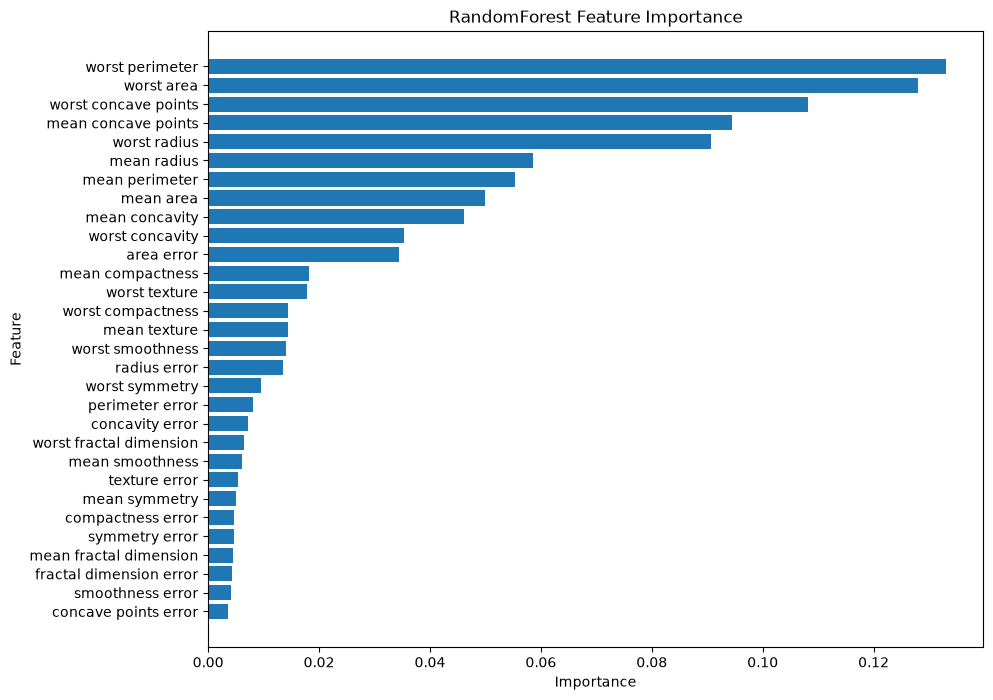

                    Feature  Importance
3                 mean area    0.008772
15        compactness error    0.008772
22          worst perimeter    0.008772
23               worst area    0.007895
7       mean concave points    0.007895
0               mean radius    0.007018
21            worst texture    0.007018
20             worst radius    0.007018
17     concave points error    0.006140
27     worst concave points    0.005263
29  worst fractal dimension    0.005263
4           mean smoothness    0.005263
10             radius error    0.004386
2            mean perimeter    0.004386
24         worst smoothness    0.003509
18           symmetry error    0.003509
9    mean fractal dimension    0.003509
14         smoothness error    0.001754
16          concavity error    0.001754
28           worst symmetry    0.000877
6            mean concavity    0.000877
13               area error    0.000877
12          perimeter error    0.000000
11            texture error    0.000000


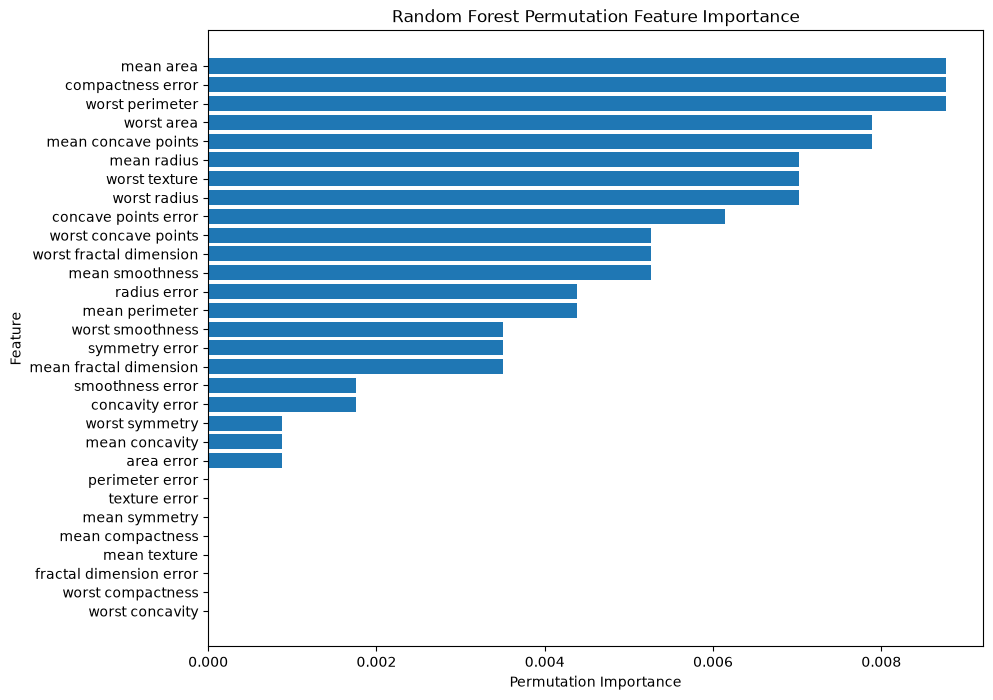

In [10]:
from sklearn.inspection import permutation_importance

plt.figure(figsize=(10,8))
plt.barh(feature_importance_df["Feature"],feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("RandomForest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

perm_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
})

perm_importance_df = perm_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(perm_importance_df)
plt.figure(figsize=(10, 8))

plt.barh(
    perm_importance_df["Feature"],
    perm_importance_df["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

lr.fit(X_train, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


                    Feature  Coefficient  Absolute Coefficient
21            worst texture    -1.255088              1.255088
10             radius error    -1.082965              1.082965
27     worst concave points    -0.953686              0.953686
23               worst area    -0.947756              0.947756
20             worst radius    -0.947616              0.947616
28           worst symmetry    -0.939181              0.939181
13               area error    -0.929104              0.929104
26          worst concavity    -0.823151              0.823151
22          worst perimeter    -0.763220              0.763220
24         worst smoothness    -0.746625              0.746625
7       mean concave points    -0.704156              0.704156
5          mean compactness     0.648342              0.648342
15        compactness error     0.647227              0.647227
6            mean concavity    -0.602103              0.602103
1              mean texture    -0.552698              0

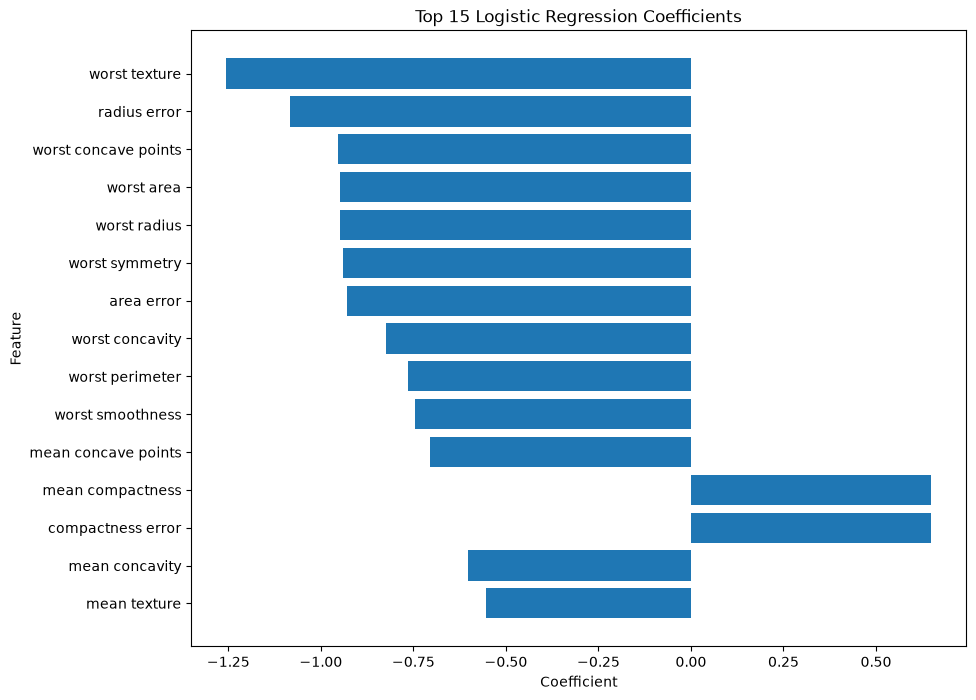

In [13]:
coefficients = lr.named_steps["lr"].coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

coefficient_df["Absolute Coefficient"] = coefficient_df["Coefficient"].abs()

coefficient_df = coefficient_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print(coefficient_df)
top_15_coefficients = coefficient_df.head(15)

plt.figure(figsize=(10, 8))

plt.barh(
    top_15_coefficients["Feature"],
    top_15_coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Logistic Regression Coefficients")

plt.gca().invert_yaxis()

plt.show()

In [14]:
comparison_df = pd.DataFrame({
    "Feature": X.columns
})

comparison_df = comparison_df.merge(
    feature_importance_df,
    on="Feature"
)

comparison_df = comparison_df.merge(
    perm_importance_df,
    on="Feature",
    suffixes=("_RF", "_Permutation")
)

comparison_df = comparison_df.merge(
    coefficient_df[
        ["Feature", "Coefficient", "Absolute Coefficient"]
    ],
    on="Feature"
)

comparison_df.head()

,Feature,Importance_RF,Importance_Permutation,Coefficient,Absolute Coefficient
0,mean radius,0.058662,0.007018,-0.511479,0.511479
1,mean texture,0.014317,0.000000,-0.552698,0.552698
2,mean perimeter,0.055242,0.004386,-0.476298,0.476298
3,mean area,0.049938,0.008772,-0.541059,0.541059
4,mean smoothness,0.006168,0.005263,-0.212479,0.212479


In [15]:
comparison_rf = comparison_df.sort_values(
    by="Importance_RF",
    ascending=False
)

print(comparison_rf.head(10))

                 Feature  Importance_RF  Importance_Permutation  Coefficient  \
22       worst perimeter       0.133100                0.008772    -0.763220   
23            worst area       0.128052                0.007895    -0.947756   
27  worst concave points       0.108107                0.005263    -0.953686   
7    mean concave points       0.094414                0.007895    -0.704156   
20          worst radius       0.090639                0.007018    -0.947616   
0            mean radius       0.058662                0.007018    -0.511479   
2         mean perimeter       0.055242                0.004386    -0.476298   
3              mean area       0.049938                0.008772    -0.541059   
6         mean concavity       0.046207                0.000877    -0.602103   
26       worst concavity       0.035357                0.000000    -0.823151   

    Absolute Coefficient  
22              0.763220  
23              0.947756  
27              0.953686  
7          

In [16]:
print("Top 10 - Random Forest Importance")
print(
    feature_importance_df[
        ["Feature", "Importance"]
    ].head(10)
)

print("\nTop 10 - Permutation Importance")
print(
    perm_importance_df[
        ["Feature", "Importance"]
    ].head(10)
)

print("\nTop 10 - Logistic Regression Coefficients")
print(
    coefficient_df[
        ["Feature", "Coefficient", "Absolute Coefficient"]
    ].head(10)
)

Top 10 - Random Forest Importance
                 Feature  Importance
22       worst perimeter    0.133100
23            worst area    0.128052
27  worst concave points    0.108107
7    mean concave points    0.094414
20          worst radius    0.090639
0            mean radius    0.058662
2         mean perimeter    0.055242
3              mean area    0.049938
6         mean concavity    0.046207
26       worst concavity    0.035357

Top 10 - Permutation Importance
                 Feature  Importance
3              mean area    0.008772
15     compactness error    0.008772
22       worst perimeter    0.008772
23            worst area    0.007895
7    mean concave points    0.007895
0            mean radius    0.007018
21         worst texture    0.007018
20          worst radius    0.007018
17  concave points error    0.006140
27  worst concave points    0.005263

Top 10 - Logistic Regression Coefficients
                 Feature  Coefficient  Absolute Coefficient
21         worst

Model Interpretability Summary

In this project, three different techniques were used to understand which features were important for predicting whether a tumor was malignant or benign.

1. Random Forest Feature Importance

Random Forest's built-in feature importance identified features such as:

worst perimeter
worst area
worst concave points
mean concave points
worst radius

These features were heavily used by the Random Forest when making predictions.

2. Permutation Importance

Permutation importance measured how much model performance changed when the values of individual features were randomly shuffled.

Some of the most important features included:

mean area
compactness error
worst perimeter
worst area
mean concave points

Because several features in the dataset are correlated, shuffling one feature may not cause a large performance drop if other related features provide similar information.

3. Logistic Regression Coefficients

Logistic Regression coefficients showed both the strength and direction of each feature's influence.

Since the target encoding was:

0 = malignant
1 = benign
Negative coefficients pushed predictions toward malignant
Positive coefficients pushed predictions toward benign

Features such as worst texture, worst concave points, worst area, and worst radius had relatively large coefficient magnitudes.

Overall Conclusion

Several features appeared important across multiple methods, particularly features related to:

tumor size
perimeter
area
radius
concavity
concave points

However, feature importance should not be interpreted as causation. These methods explain how the machine learning models used the available features, not whether those features directly cause cancer.